In [8]:
import pandas as pd
import numpy as np
import torch
import joblib
import shap
import matplotlib.pyplot as plt
import torch.nn as nn
plt.rcParams['font.family'] = 'SimHei'
plt.rcParams['axes.unicode_minus'] = False


In [11]:
# 1. 重建网络（必须和训练时完全一致）
class MLP_REG(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(3, 16),
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(16, 8),
            nn.BatchNorm1d(8),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(8, 1)
        )
    def forward(self, x):
        return self.net(x)

model = MLP_REG()
model.load_state_dict(torch.load('mlp_reg_best.pth'))
model.eval()

# 2. 加载 scaler
scaler = joblib.load('scaler.pkl')

In [12]:
df = pd.read_csv(r'E:\miniconda\ChineseSuperLeague\data\features.csv')
X = df[['home_last3_goals', 'away_last3_concede', 'home_last2_loss']].values
y = (df['result'] == 'H').astype(int)

# 任取第 0 场比赛（你可以改 idx 换别的场）
idx = 0
x_single = X[idx:idx+1]          # (1,3)
x_scaled = scaler.transform(x_single)

print(f'选取第 {idx} 场比赛')
print(f'原始特征：主队近3进球={x_single[0,0]:.0f}，客队近3失球={x_single[0,1]:.0f}，主队连败={x_single[0,2]:.0f}')
print(f'实际结果：{"主胜" if y[idx] else "非主胜"}')

选取第 0 场比赛
原始特征：主队近3进球=2，客队近3失球=6，主队连败=1
实际结果：非主胜


In [15]:
def model_prob(x):
    """输入 numpy (batch,3) → 输出概率 (batch,)"""
    x = torch.tensor(x, dtype=torch.float32)
    with torch.no_grad():
        logits = model(x)
        prob   = torch.sigmoid(logits).numpy().squeeze(-1)
    return prob

# 用训练集前 50 条当背景（加速计算）
background = scaler.transform(X[:50])
explainer  = shap.KernelExplainer(model_prob, background)

  0%|          | 0/1 [00:00<?, ?it/s]

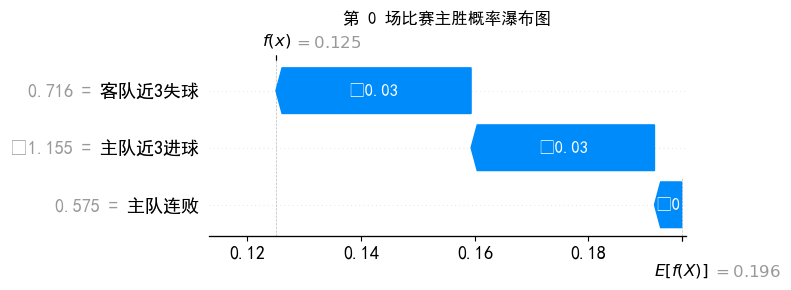

In [27]:
# Cell 5：瀑布图（中文无警告 + 高清保存）
import matplotlib.pyplot as plt
import shap, os

plt.rcParams['font.family'] = 'SimHei'        # ← 新增
plt.rcParams['axes.unicode_minus'] = False    # ← 新增

# 计算 SHAP 值
x_scaled_np = x_scaled
explainer   = shap.KernelExplainer(model_prob, background)
shap_values = explainer.shap_values(x_scaled_np)[0]

# 封装成 Explanation
exp = shap.Explanation(
    values=shap_values,
    base_values=explainer.expected_value,
    data=x_scaled_np[0],
    feature_names=['主队近3进球', '客队近3失球', '主队连败']
)

# 瀑布图 + 保存
os.makedirs('figures', exist_ok=True)
plt.figure(figsize=(6, 4))
shap.plots.waterfall(exp, show=False)
plt.title('第 0 场比赛主胜概率瀑布图')
plt.tight_layout()
plt.savefig('figures/shap_waterfall_game0.png', dpi=300, bbox_inches='tight')
# 把缺字警告屏蔽掉
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
plt.savefig('figures/shap_waterfall_game0.png', dpi=300, bbox_inches='tight')
plt.show()
